In [1]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# Cat Qubit Optimization

Online CMA-ES optimization for dissipative cat qubit stabilization.
Connects `models.py` → `Model_to_halflife.py` → `cmaes`.

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
MODEL = "moon_cat"        # standard_cat, moon_cat, kerr_cat, drift_compensated_cat, effective_cat
DRIFT = "frequency"                # none, amplitude, frequency, both
N_EPOCHS = 30
BATCH_SIZE = 12
TARGET_BIAS = 500.0
LAMBDA_PENALTY = 0.001
SEED = 32
OBJECTIVE = "log_sum_penalty"   # see objectives.py for options
OBJECTIVE_KWARGS = {}           # extra kwargs for the objective

In [3]:
import sys, os, time
sys.path.insert(0, "src")
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["JAX_PLATFORMS"] = "cpu"
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from IPython.display import display
from concurrent.futures import ThreadPoolExecutor, as_completed
from cmaes import SepCMA
from objectives import OBJECTIVES
from optimizer import run_optimization
from models import MODELS, NA, NB, compute_alpha
from Model_to_halflife import measure_lifetime
from drift_hamiltonians import FULL_HAMILTONIANS_WITH_DRIFT

In [4]:
print(f"Model: {MODEL}")
print(f"Drift: {DRIFT}")
print(f"Target bias: η={TARGET_BIAS}")

Model: moon_cat
Drift: frequency
Target bias: η=500.0


In [5]:
print('Running optimization...')
history = run_optimization(
    model_name=MODEL,
    drift_type=DRIFT,
    target_bias=TARGET_BIAS,
    lambda_penalty=LAMBDA_PENALTY,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    seed=SEED,
    objective=OBJECTIVE,
    objective_kwargs=OBJECTIVE_KWARGS,
)


Running optimization...


/Users/gehadsalem/Documents/coding/ETH-Hack/.venv/lib/python3.13/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


Epoch   0/30 | reward=-103.435 | T_Z=65.1 | T_X=0.139 | η=468 | [7s]
Epoch   3/30 | reward=-121.439 | T_Z=117.6 | T_X=0.147 | η=801 | [17s]
Epoch   6/30 | reward=-63.198 | T_Z=94.1 | T_X=0.125 | η=752 | [26s]
Epoch   9/30 | reward=-117.240 | T_Z=78.7 | T_X=0.134 | η=586 | [34s]
Epoch  12/30 | reward=-117.267 | T_Z=56.0 | T_X=0.097 | η=579 | [43s]
Epoch  15/30 | reward=-50.255 | T_Z=64.3 | T_X=0.123 | η=521 | [52s]
Epoch  18/30 | reward=-14.294 | T_Z=58.7 | T_X=0.114 | η=514 | [62s]
Epoch  21/30 | reward=-4.015 | T_Z=54.8 | T_X=0.109 | η=501 | [70s]
Epoch  24/30 | reward=-13.257 | T_Z=58.1 | T_X=0.114 | η=512 | [78s]
Epoch  27/30 | reward=-33.875 | T_Z=58.6 | T_X=0.114 | η=513 | [87s]
Epoch  29/30 | reward=-37.586 | T_Z=59.7 | T_X=0.117 | η=509 | [94s]

Done. Final: T_Z=59.7, T_X=0.117, η=509
Params: ['0.5073', '0.6730', '4.7900', '-0.6556', '0.1821', '-0.4525']


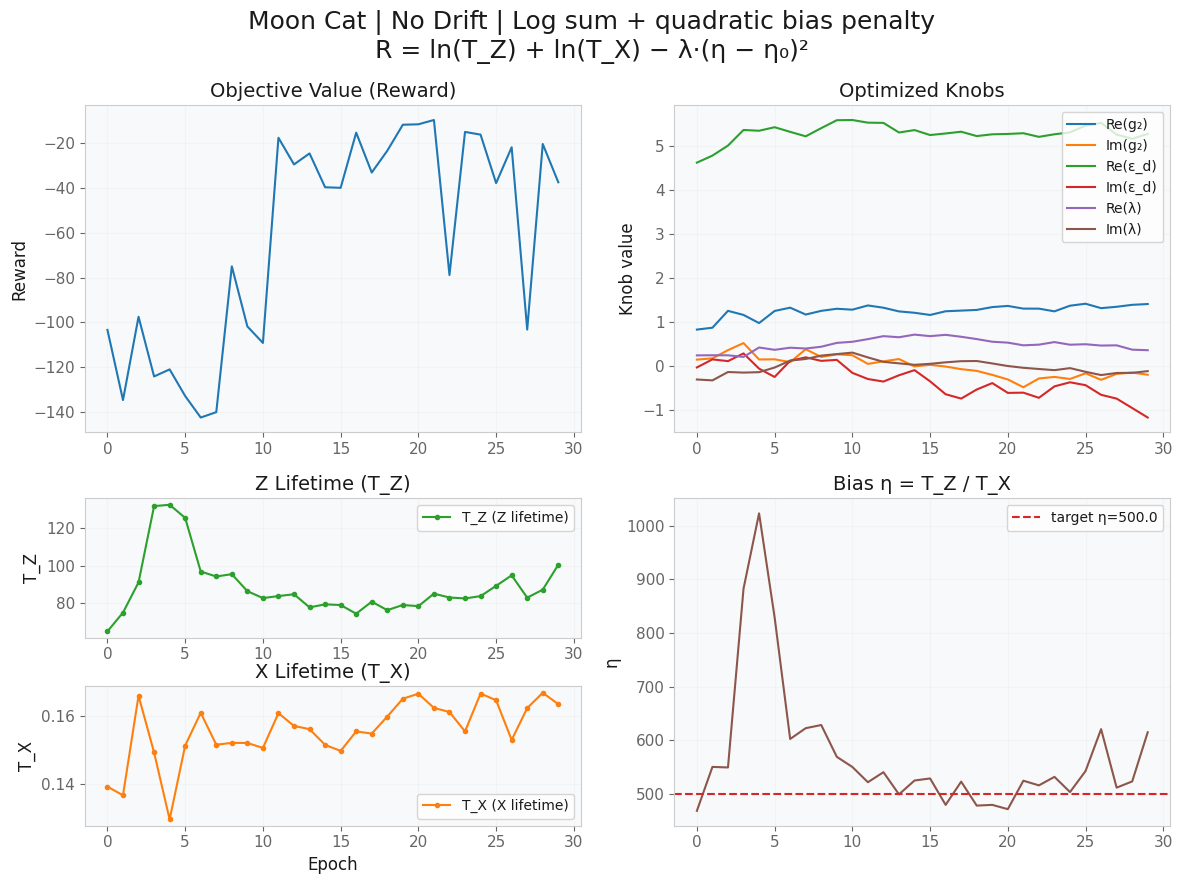

Final: T_Z=100.6, T_X=0.1635, η=615


In [22]:
DARK_MODE = False

if DARK_MODE:
    BG = '#1a1a1a'
    FG = '#cccccc'
    GRID = '#333333'
    FIG_BG = '#111111'
    SPINE = '#444444'
    TICK = '#888888'
    LEGEND_BG = '#222222'
else:
    BG = '#f8f9fa'
    FG = '#1a1a1a'
    GRID = '#dddddd'
    FIG_BG = '#ffffff'
    SPINE = '#cccccc'
    TICK = '#666666'
    LEGEND_BG = '#ffffff'

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'text.color': FG,
    'axes.facecolor': BG,
    'axes.edgecolor': SPINE,
    'axes.labelcolor': FG,
    'axes.titlecolor': FG,
    'xtick.color': TICK,
    'ytick.color': TICK,
    'legend.facecolor': LEGEND_BG,
    'legend.edgecolor': SPINE,
    'legend.labelcolor': FG,
    'grid.color': GRID,
    'figure.facecolor': FIG_BG,
})

e = np.arange(len(history["reward"]))
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2)
fig.suptitle(
    f"{MODELS[MODEL]['label']} | {FULL_HAMILTONIANS_WITH_DRIFT[DRIFT]['label']} | "
    f"{OBJECTIVES[OBJECTIVE]['label']}\n"
    f"{OBJECTIVES[OBJECTIVE]['eq']}",
    fontsize=18, color=FG
)

ax_reward = fig.add_subplot(gs[0, 0])
ax_knobs = fig.add_subplot(gs[0, 1])

gs_life = gs[1, 0].subgridspec(2, 1, hspace=0.35)
ax_tz = fig.add_subplot(gs_life[0])
ax_tx = fig.add_subplot(gs_life[1])

ax_eta = fig.add_subplot(gs[1, 1])

knob_col = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f']
if not DARK_MODE:
    knob_col = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

ax_reward.plot(e, history["reward"], color=knob_col[0])
ax_reward.set_title("Objective Value (Reward)")
ax_reward.set_ylabel("Reward")
ax_reward.grid(True, alpha=0.2)
ax_reward.set_facecolor(BG)

mp = np.array(history["mean_params"])
for i in range(mp.shape[1]):
    ax_knobs.plot(e, mp[:, i], label=MODELS[MODEL]["knob_names"][i], color=knob_col[i % len(knob_col)])
ax_knobs.set_title("Optimized Knobs")
ax_knobs.set_ylabel("Knob value")
ax_knobs.legend(fontsize=10)
ax_knobs.grid(True, alpha=0.2)
ax_knobs.set_facecolor(BG)

ax_tz.plot(e, history["tz"], "o-", markersize=3, color=knob_col[2], label="T_Z (Z lifetime)")
ax_tz.set_title("Z Lifetime (T_Z)")
ax_tz.set_ylabel("T_Z")
ax_tz.legend(fontsize=10)
ax_tz.grid(True, alpha=0.2)
ax_tz.set_facecolor(BG)

ax_tx.plot(e, history["tx"], "o-", color=knob_col[1], markersize=3, label="T_X (X lifetime)")
ax_tx.set_title("X Lifetime (T_X)")
ax_tx.set_ylabel("T_X")
ax_tx.set_xlabel("Epoch")
ax_tx.legend(fontsize=10)
ax_tx.grid(True, alpha=0.2)
ax_tx.set_facecolor(BG)

ax_eta.plot(e, history["eta"], color=knob_col[5])
ax_eta.axhline(TARGET_BIAS, color=knob_col[3], ls="--", label=f"target η={TARGET_BIAS}")
ax_eta.set_title("Bias η = T_Z / T_X")
ax_eta.set_ylabel("η")
ax_eta.legend(fontsize=10)
ax_eta.grid(True, alpha=0.2)
ax_eta.set_facecolor(BG)

plt.tight_layout()
plt.show()

tz_last = history["tz"][-1]
tx_last = history["tx"][-1]
print(f"Final: T_Z={tz_last:.1f}, T_X={tx_last:.4f}, η={tz_last / tx_last:.0f}")

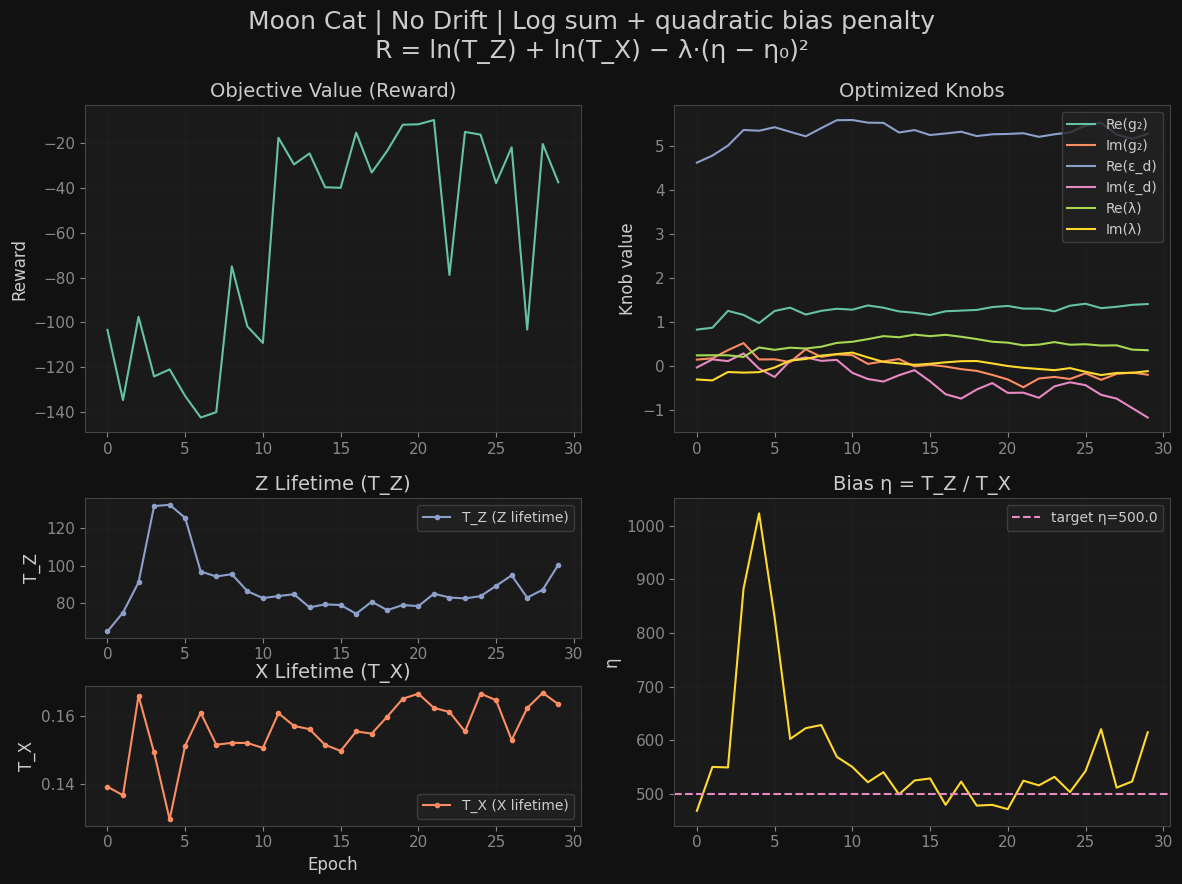

Final: T_Z=100.6, T_X=0.1635, η=615


In [23]:
DARK_MODE = True  # True for dark theme, False for light theme

if DARK_MODE:
    BG = "#1a1a1a"
    FG = "#cccccc"
    GRID = "#333333"
    FIG_BG = "#111111"
    SPINE = "#444444"
    TICK = "#888888"
    LEGEND_BG = "#222222"
else:
    BG = "#f8f9fa"
    FG = "#1a1a1a"
    GRID = "#dddddd"
    FIG_BG = "#ffffff"
    SPINE = "#cccccc"
    TICK = "#666666"
    LEGEND_BG = "#ffffff"

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "text.color": FG,
        "axes.facecolor": BG,
        "axes.edgecolor": SPINE,
        "axes.labelcolor": FG,
        "axes.titlecolor": FG,
        "xtick.color": TICK,
        "ytick.color": TICK,
        "legend.facecolor": LEGEND_BG,
        "legend.edgecolor": SPINE,
        "legend.labelcolor": FG,
        "grid.color": GRID,
        "figure.facecolor": FIG_BG,
    }
)

e = np.arange(len(history["reward"]))
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2)
fig.suptitle(
    f"{MODELS[MODEL]['label']} | {FULL_HAMILTONIANS_WITH_DRIFT[DRIFT]['label']} | "
    f"{OBJECTIVES[OBJECTIVE]['label']}\n"
    f"{OBJECTIVES[OBJECTIVE]['eq']}",
    fontsize=18,
    color=FG,
)

ax_reward = fig.add_subplot(gs[0, 0])
ax_knobs = fig.add_subplot(gs[0, 1])

gs_life = gs[1, 0].subgridspec(2, 1, hspace=0.35)
ax_tz = fig.add_subplot(gs_life[0])
ax_tx = fig.add_subplot(gs_life[1])

ax_eta = fig.add_subplot(gs[1, 1])

knob_col = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f"]
if not DARK_MODE:
    knob_col = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

ax_reward.plot(e, history["reward"], color=knob_col[0])
ax_reward.set_title("Objective Value (Reward)")
ax_reward.set_ylabel("Reward")
ax_reward.grid(True, alpha=0.2)
ax_reward.set_facecolor(BG)

mp = np.array(history["mean_params"])
for i in range(mp.shape[1]):
    ax_knobs.plot(
        e,
        mp[:, i],
        label=MODELS[MODEL]["knob_names"][i],
        color=knob_col[i % len(knob_col)],
    )
ax_knobs.set_title("Optimized Knobs")
ax_knobs.set_ylabel("Knob value")
ax_knobs.legend(fontsize=10)
ax_knobs.grid(True, alpha=0.2)
ax_knobs.set_facecolor(BG)

ax_tz.plot(
    e, history["tz"], "o-", markersize=3, color=knob_col[2], label="T_Z (Z lifetime)"
)
ax_tz.set_title("Z Lifetime (T_Z)")
ax_tz.set_ylabel("T_Z")
ax_tz.legend(fontsize=10)
ax_tz.grid(True, alpha=0.2)
ax_tz.set_facecolor(BG)

ax_tx.plot(
    e, history["tx"], "o-", color=knob_col[1], markersize=3, label="T_X (X lifetime)"
)
ax_tx.set_title("X Lifetime (T_X)")
ax_tx.set_ylabel("T_X")
ax_tx.set_xlabel("Epoch")
ax_tx.legend(fontsize=10)
ax_tx.grid(True, alpha=0.2)
ax_tx.set_facecolor(BG)

ax_eta.plot(e, history["eta"], color=knob_col[5])
ax_eta.axhline(TARGET_BIAS, color=knob_col[3], ls="--", label=f"target η={TARGET_BIAS}")
ax_eta.set_title("Bias η = T_Z / T_X")
ax_eta.set_ylabel("η")
ax_eta.legend(fontsize=10)
ax_eta.grid(True, alpha=0.2)
ax_eta.set_facecolor(BG)

plt.tight_layout()
plt.show()

tz_last = history["tz"][-1]
tx_last = history["tx"][-1]
print(f"Final: T_Z={tz_last:.1f}, T_X={tx_last:.4f}, η={tz_last / tx_last:.0f}")


---
### Notes
- Swap `MODEL` and `DRIFT` at the top to test different cat flavors or drift scenarios
- The `effective_cat` is much faster (single-mode) — useful for quick iterations
- `kerr_cat` and `drift_compensated_cat` have 5 knobs; `moon_cat` has 6